<a href="https://colab.research.google.com/github/rlpinhal/Aprendendo_Python/blob/main/aula_10_fun%C3%A7%C3%B5es_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import de bibliotecas
import pandas as pd

In [ ]:
#Lendo todos os meses

jan_ler_dados = pd.read_csv('/content/vendas_janeiro.csv')

fev_ler_dados = pd.read_csv('/content/vendas_fevereiro.csv')

mar_ler_dados = pd.read_csv('/content/vendas_marco.csv')

#função para verificar o tipo de tabela
type(jan_ler_dados)

pandas.core.frame.DataFrame

In [ ]:
# Unindo janeiro e fevereiro
jan_fev_juntos = pd.concat([jan_ler_dados, fev_ler_dados], ignore_index = True)

jan_fev_juntos.to_csv("jan_fev_juntos.csv", index=False)

In [ ]:
# Unindo Janeiro/Feveireiro com Março
jan_fev_dados = pd.read_csv('/content/jan_fev_juntos.csv')

trimestre=pd.concat([jan_fev_juntos,mar_ler_dados], ignore_index = True)

trimestre.to_csv("trimestre.csv",index=False)

In [ ]:
#Imprimindo a tabela para ver se de fato concatenou tudo
display(trimestre)

,Data,Produto,Preço,Qtd,Loja
0,2024-01-14,Microfone Condensador,654,9,Rio de Janeiro
1,2024-01-1,Baixo 4 Cordas,1169,1,Rio de Janeiro
2,2024-01-4,Bateria Acústica,2964,1,Curitiba
3,2024-01-27,Violão Nylon,4352,6,Rio de Janeiro
4,2024-01-12,Baixo 4 Cordas,709,10,São Paulo
...,...,...,...,...,...
160,2024-03-21,Teclado Digital,2654,4,Rio de Janeiro
161,2024-03-14,Amplificador 50W,1170,8,Curitiba
162,2024-03-24,Violão Nylon,3556,10,Belo Horizonte
163,2024-03-28,Bateria Acústica,2742,1,São Paulo


### Calculando os KPIs da planilha `trimestre`

Primeiro, vamos calcular a receita de cada venda (Preço * Quantidade).

In [ ]:
trimestre['Receita'] = trimestre['Preço'] * trimestre['Qtd']
display(trimestre.head())

,Data,Produto,Preço,Qtd,Loja,Receita
0,2024-01-14,Microfone Condensador,654,9,Rio de Janeiro,5886
1,2024-01-1,Baixo 4 Cordas,1169,1,Rio de Janeiro,1169
2,2024-01-4,Bateria Acústica,2964,1,Curitiba,2964
3,2024-01-27,Violão Nylon,4352,6,Rio de Janeiro,26112
4,2024-01-12,Baixo 4 Cordas,709,10,São Paulo,7090


#### 1. Faturamento Bruto (Gross Revenue)

In [ ]:
faturamento_bruto = trimestre['Receita'].sum()
print(f"Faturamento Bruto Total: R$ {faturamento_bruto:,.2f}")

Faturamento Bruto Total: R$ 2,233,098.00


#### 2. Ticket Médio (Average Ticket)

In [ ]:
ticket_medio = trimestre['Receita'].mean()
print(f"Ticket Médio por Venda: R$ {ticket_medio:,.2f}")

Ticket Médio por Venda: R$ 13,533.93


#### 3. Top Seller (Produto com maior receita)

In [ ]:
top_seller = trimestre.groupby('Produto')['Receita'].sum().sort_values(ascending=False).head(1)
print("Produto Top Seller (maior receita):")
display(top_seller)

Produto Top Seller (maior receita):


,Receita
Produto,
Amplificador 50W,399229


#### 4. Ranking Regional (Desempenho por unidade física)

In [ ]:
ranking_regional = trimestre.groupby('Loja')['Receita'].sum().sort_values(ascending=False)
print("Ranking Regional (Receita por Loja):")
display(ranking_regional)

Ranking Regional (Receita por Loja):


,Receita
Loja,
São Paulo,685366
Curitiba,572846
Rio de Janeiro,566308
Belo Horizonte,408578


### Visualização dos KPIs

#### Top Seller (Produtos com maior receita)

/tmp/ipykernel_8268/3349327867.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_sellers.index, y=top_5_sellers.values, palette='viridis')


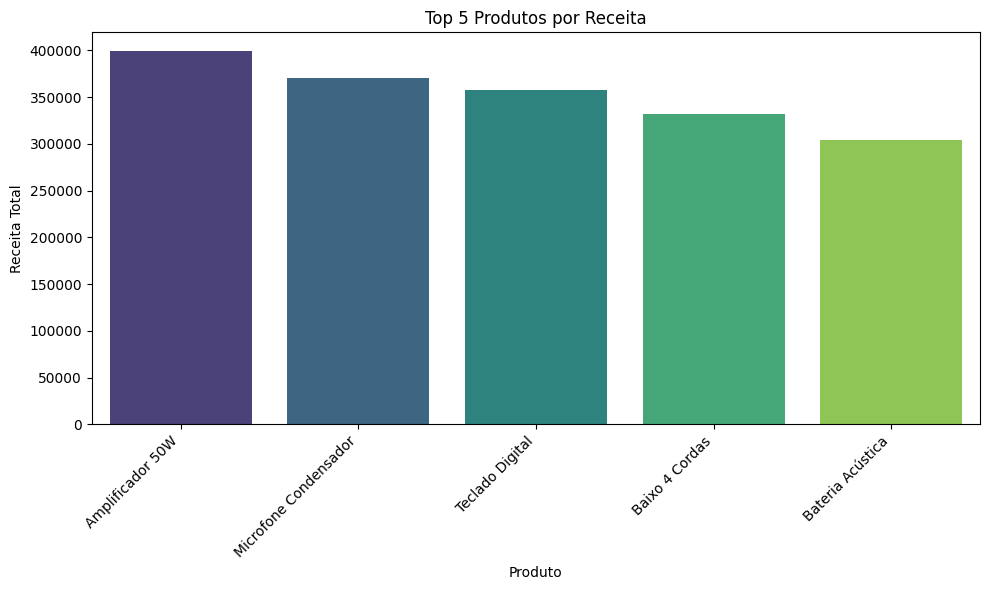

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_5_sellers = trimestre.groupby('Produto')['Receita'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_sellers.index, y=top_5_sellers.values, hue=top_5_sellers.index, palette='viridis', legend=False)
plt.title('Top 5 Produtos por Receita')
plt.xlabel('Produto')
plt.ylabel('Receita Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Ranking Regional (Receita por Loja)

/tmp/ipykernel_8268/2592085652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranking_regional.index, y=ranking_regional.values, palette='magma')


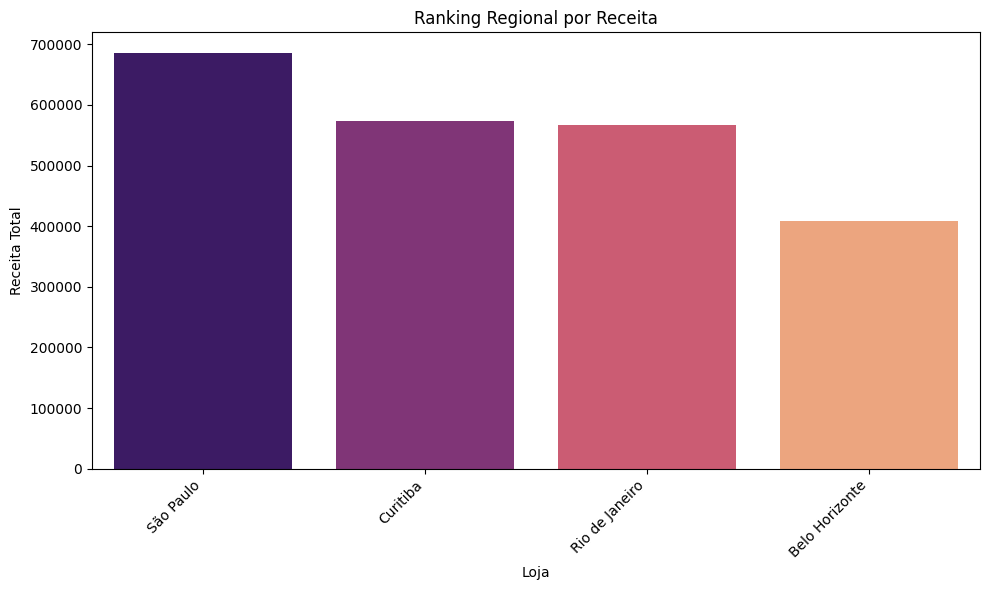

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_regional.index, y=ranking_regional.values, hue=ranking_regional.index, palette='magma', legend=False)
plt.title('Ranking Regional por Receita')
plt.xlabel('Loja')
plt.ylabel('Receita Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()